# Short Tandem Repeats — SNP frequency

SNP allele-frequency analysis around Short Tandem Repeat (STR) motifs, mirroring the Z-DNA
pipeline (3-part split: `LeftFlank | Locus | RightFlank`, locus normalized to **180 bins**).

Three comparisons are produced:

1. **§5 detected vs undetected vs control** — the gofae-model detected STR set
   (`Short_Tandem_Repeat_detected.bed`), the undetected complement (all-test STR ∖ detected)
   from `Short_Tandem_Repeat_test.csv`, and a shuffled genomic control.
2. **§6 all-test STR vs control** — every `label == 'Short_Tandem_Repeat'` row from the test
   CSV against its own shuffled control (exclusion built from all-test STR ∪ NCNR ∪ hg38 gaps).

The motif region is **not subdivided** into repeat/spacer parts (STR has no spacer); each
locus is rescaled to 180 bins regardless of length, matching the Z-DNA splitter.


# Library

Load this before running the rest of the notebook.

In [2]:
try:
    get_ipython().run_line_magic('load_ext', 'rpy2.ipython')
    print('rpy2 loaded')
except Exception as e:
    print('rpy2 not available (expected for the matplotlib-only path):', e)

rpy2 not available (expected for the matplotlib-only path): No module named 'rpy2'


In [3]:
import os, sys, re, subprocess, random
from pathlib import Path
import pandas as pd
import numpy as np

BASE    = os.environ.get("SNP_AF_BASE", "/path/to/snp_af_analysis")
WORKDIR = f"{BASE}/results/str_notebook_detected_run"
Path(WORKDIR).mkdir(parents=True, exist_ok=True)
os.chdir(WORKDIR)

os.environ["BASE"]        = BASE
os.environ["CHROM_SIZES"] = f"{BASE}/reference/hg38.chrom.sizes"
os.environ["GAPS_BED"]    = f"{BASE}/annotations/hg38_gaps.bed"
os.environ["CODING_BED"]  = f"{BASE}/annotations/coding_regions.bed"
os.environ["REPEAT_BED"]  = f"{BASE}/annotations/repetitive_elements.bed"
os.environ["SNP_DIR"]     = f"{BASE}/snp_data/gnomad"
os.environ["PATH"]        = os.environ.get("BEDTOOLS_BIN", "") + ":" + os.environ["PATH"]
# Stage-1 (NR-Contrastive) outputs and experimental splits
# Override with environment variables; the defaults are the paths used for the paper.
PU_RESULTS      = os.environ.get("NONB_PU_RESULTS",
    "/path/to/pu_results")
EXPERIMENT_DATA = os.environ.get("NONB_EXPERIMENT_DATA",
    "/path/to/Experiment_Data")
IWTOMICS_DIR    = os.environ.get("IWTOMICS_DIR",
    "/path/to/nonb-nrcl-paper/snp_analysis/iwtomics")


random.seed(42)
np.random.seed(42)
print("cwd:", os.getcwd())
print("bedtools:", subprocess.run("which bedtools", shell=True, capture_output=True, text=True).stdout.strip())

cwd: /data/haotian/qianying/snp_af_analysis/results/str_notebook_detected_run
bedtools: /home/haz19024/softwares/bedtools2/bin/bedtools


# 5. STR — detected vs undetected vs control

All intermediate files for §5 live in `results/str_notebook_detected_run/`.

## 5.1 Retrieve annotation (detected)

Load gofae-detected STR motifs from `Short_Tandem_Repeat_detected.bed`. Columns: `chr, win_start, win_end, strand, motif_start, motif_end, sequence, p_value, q_value`. Only `motif_start`/`motif_end` are used (1-based inclusive → 0-based half-open). STR has no spacer, so column 4 of the output BED is just the motif length placeholder.

In [4]:
STR_BED = f"{PU_RESULTS}/Short_Tandem_Repeat/Short_Tandem_Repeat_detected.bed"

s_df = pd.read_csv(STR_BED, sep="\t")
print(f"detected STR rows: {len(s_df)}")

s_df = s_df.dropna(subset=["motif_start", "motif_end"]).reset_index(drop=True)
s_df["motif_start"] = s_df["motif_start"].astype(int) - 1   # 1-based inclusive -> 0-based half-open
s_df["motif_end"]   = s_df["motif_end"].astype(int)
s_df = s_df.drop_duplicates(subset=["chr","motif_start","motif_end","strand"]).reset_index(drop=True)
s_df["motif_length"] = s_df["motif_end"] - s_df["motif_start"]
print(f"after dedup: {len(s_df)}")

s_df[["chr","motif_start","motif_end","motif_length"]].to_csv(
    "STR.bed", sep="\t", header=False, index=False)
print(f"wrote STR.bed with {len(s_df)} rows")

detected STR rows: 224394
after dedup: 224394
wrote STR.bed with 224394 rows


NCNR filter (remove overlaps with coding + repetitive) and apply the published 100-bp motif length threshold.

In [5]:
%%bash
set -euo pipefail

if [ ! -f NCNR.hg38.bed ]; then
    cat "$CODING_BED" "$REPEAT_BED" | sort -k1,1 -k2,2n | bedtools merge -i stdin > NCNR.hg38.bed
fi

bedtools intersect -a STR.bed -b NCNR.hg38.bed -v > NCNRSTR.bed
awk '{if ($3-$2<=100) print $0}' NCNRSTR.bed > NCNR.STR.100threshold.bed
bedtools sort -i NCNR.STR.100threshold.bed > NCNR.STR.100threshold.sorted.bed

wc -l STR.bed NCNRSTR.bed NCNR.STR.100threshold.sorted.bed

 224394 STR.bed
  55841 NCNRSTR.bed
  55841 NCNR.STR.100threshold.sorted.bed
 336076 total


## 5.2 Create Flanks

Add 2 kb flanks on each side. Output 8-col BED: `chrom, flank_start, flank_end, motif_length, strand, locus_start, locus_end, motif_length_again`.

In [6]:
%%bash
set -euo pipefail
paste NCNR.STR.100threshold.sorted.bed \
    <(bedtools slop -i NCNR.STR.100threshold.sorted.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2, "+", $2, $3, $4}' \
  > NCNRSTR.flanked.bed

wc -l NCNRSTR.flanked.bed
head -2 NCNRSTR.flanked.bed

55841 NCNRSTR.flanked.bed
chr1	130627	134637	10	+	132627	132637	10
chr1	734186	738196	10	+	736186	736196	10


## 5.3 Create Controls

Shuffle exclusion unions THREE sources so controls never fall in forbidden regions: (1) detected STR motifs (after NCNR/threshold), (2) NCNR, (3) `hg38_gaps.bed`. Gaps matter here: leaving them out lets controls land in centromeric/telomeric N-runs and artificially depresses the control SNP baseline.

In [7]:
%%bash
set -euo pipefail

cut -f 1-3 NCNR.STR.100threshold.sorted.bed > _temp_STR

cat _temp_STR "$GAPS_BED" NCNR.hg38.bed \
  | cut -f1-3 \
  | sort -k1,1 -k2,2n | bedtools merge -i stdin > exclude_STR.bed

bedtools shuffle -i NCNR.STR.100threshold.sorted.bed \
    -excl exclude_STR.bed -g "$CHROM_SIZES" \
    -chrom -f 0 -noOverlapping -seed 42 > _temp_STR_shuffled
bedtools sort -i _temp_STR_shuffled > NCNRSTR.shuffled.bed

paste NCNRSTR.shuffled.bed \
    <(bedtools slop -i NCNRSTR.shuffled.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2+1, "+", $2, $3, $4}' \
  > NCNRSTR.shuffled.flanked.bed

rm -f _temp_STR _temp_STR_shuffled
wc -l NCNRSTR.shuffled.flanked.bed
head -2 NCNRSTR.shuffled.flanked.bed

55841 NCNRSTR.shuffled.flanked.bed
chr1	44339	48351	13	+	46339	46351	12
chr1	96760	100771	12	+	98760	98771	11


## 5.4 Pick non-overlapping windows

Greedy pass that, within each overlap cluster on a chromosome, keeps one random motif and drops the rest. Removes pseudo-replication from the 4 kb flanked windows.

In [8]:
def locuschoice(in_bed, out_bed, seed=42):
    rng = random.Random(seed)
    last_chrom = "chr0"
    last_end = 0
    tochoose = []
    nkept = 0
    with open(in_bed) as f_in, open(out_bed, "w") as f_out:
        for line in f_in:
            arr = line.rstrip("\n").split("\t")
            chrom = arr[0]; ws = int(arr[1]); we = int(arr[2])
            if chrom == last_chrom:
                if ws < last_end:
                    tochoose.append(arr); last_end = we
                else:
                    chosen = tochoose[rng.randint(0, len(tochoose)-1)]
                    f_out.write("\t".join(chosen) + "\n"); nkept += 1
                    tochoose = [arr]; last_end = we
            else:
                if tochoose:
                    chosen = tochoose[rng.randint(0, len(tochoose)-1)]
                    f_out.write("\t".join(chosen) + "\n"); nkept += 1
                tochoose = [arr]; last_chrom = chrom; last_end = we
        if tochoose:
            chosen = tochoose[rng.randint(0, len(tochoose)-1)]
            f_out.write("\t".join(chosen) + "\n"); nkept += 1
    print(f"{in_bed} -> {out_bed}: kept {nkept}")
    return nkept

locuschoice("NCNRSTR.flanked.bed",          "NCNRSTR.nooverlap.bed",          seed=42)
locuschoice("NCNRSTR.shuffled.flanked.bed", "NCNRSTR.shuffled.nooverlap.bed", seed=43)

NCNRSTR.flanked.bed -> NCNRSTR.nooverlap.bed: kept 50353
NCNRSTR.shuffled.flanked.bed -> NCNRSTR.shuffled.nooverlap.bed: kept 50769


50769

## 5.5 Split into LeftFlank | Locus | RightFlank

STR has no spacer/repeat structure, so the splitter mirrors Z-DNA's: each window becomes **3 rows** — LeftFlank, Locus (= the motif itself), RightFlank. Output is 5 columns: `chrom, start, end, locus_id, part_type`.

In [9]:
def split_str(in_bed, out_bed):
    """Split each STR flanked window into LeftFlank | Locus | RightFlank.
    Mirrors Split_ZDNA.py — STR locus is the motif region itself, no spacer/repeat partition.
    Output: 5 cols (chrom, start, end, locus_id, part_type).
    """
    loci = 0
    with open(in_bed) as fin, open(out_bed, "w") as fout:
        for line in fin:
            parts = line.rstrip("\n").split("\t")
            chrom, f_start, f_end, _length, _strand, l_start, l_end = parts[:7]
            lid = loci
            loci += 1
            fout.write(f"{chrom}\t{f_start}\t{l_start}\t{lid}\tLeftFlank\n")
            fout.write(f"{chrom}\t{l_start}\t{l_end}\t{lid}\tLocus\n")
            fout.write(f"{chrom}\t{l_end}\t{f_end}\t{lid}\tRightFlank\n")
    print(f"{in_bed} -> {out_bed}: {loci} Loci")
    return loci

n_motif = split_str("NCNRSTR.nooverlap.bed",          "NCNRSTR.split.bed")
n_ctrl  = split_str("NCNRSTR.shuffled.nooverlap.bed", "NCNRSTR.shuffled.split.bed")

N_MOTIF = n_motif
N_CTRL  = n_ctrl
print(f"\nN_MOTIF={N_MOTIF}  N_CTRL={N_CTRL}")
with open("split_counts.txt", "w") as f:
    f.write(f"N_MOTIF\t{N_MOTIF}\nN_CTRL\t{N_CTRL}\n")

NCNRSTR.nooverlap.bed -> NCNRSTR.split.bed: 50353 Loci
NCNRSTR.shuffled.nooverlap.bed -> NCNRSTR.shuffled.split.bed: 50769 Loci

N_MOTIF=50353  N_CTRL=50769


## 5.6 Intersect annotations with gnomAD

Per-chromosome `bedtools intersect` against `snp_data/gnomad/chr{N}_snps.bed` (looping per chrom keeps memory bounded vs. one giant `all_chroms_snps.bed`).

In [10]:
def intersect_per_chrom(bed_path, out_path):
    snp_dir = os.environ["SNP_DIR"]
    chroms = sorted(pd.read_csv(bed_path, sep="\t", header=None)[0].unique())
    total = 0
    with open(out_path, "w") as fout:
        for c in chroms:
            snp_file = f"{snp_dir}/{c}_snps.bed"
            if not os.path.exists(snp_file):
                print(f"  skip {c} (no {snp_file})"); continue
            cmd = (f'awk \'$1=="{c}"\' {bed_path} '
                   f'| bedtools intersect -wa -wb -a stdin -b {snp_file} -loj')
            res = subprocess.run(cmd, shell=True, capture_output=True, text=True)
            if res.stdout:
                fout.write(res.stdout)
                total += res.stdout.count("\n")
    print(f"{bed_path} -> {out_path}: {total} lines")
    return total

for p in ("NCNRSTR.split.bed", "NCNRSTR.shuffled.split.bed"):
    subprocess.run(f"bedtools sort -i {p} > _s.bed && mv _s.bed {p}", shell=True, check=True)

intersect_per_chrom("NCNRSTR.split.bed",          "NCNRSTR.gnomAD.intersect")
intersect_per_chrom("NCNRSTR.shuffled.split.bed", "NCNRSTR.gnomAD.shuffled.intersect")

  skip chrY (no /data/haotian/qianying/snp_af_analysis/snp_data/gnomad/chrY_snps.bed)
NCNRSTR.split.bed -> NCNRSTR.gnomAD.intersect: 52076954 lines
  skip chrY (no /data/haotian/qianying/snp_af_analysis/snp_data/gnomad/chrY_snps.bed)
NCNRSTR.shuffled.split.bed -> NCNRSTR.gnomAD.shuffled.intersect: 52472067 lines


52472067

## 5.7 Per-locus matrices + IWTomics permutation test

Build per-locus `(n_loci × n_bins)` matrices for left flank (100 bp), locus (180 bins), right flank (100 bp). The locus is normalized to 180 bins regardless of motif length. Then run the IWTomics-style two-sample squared-mean-difference permutation test (1000 perms, α = 0.01, min significant run length = 5).

In [11]:
MAX_FLANK   = 100
LOCUS_BINS  = 180
N_PERM      = 1000
ALPHA       = 0.01

scaledposLocus = [round(i,4) for i in np.arange(1, LOCUS_BINS*2, 2.0)/(LOCUS_BINS*2)]

def _build_matrices(intersect_path, n_loci):
    left_mat   = np.zeros((n_loci, MAX_FLANK),  dtype=np.float32)
    locus_mat  = np.zeros((n_loci, LOCUS_BINS), dtype=np.float32)
    right_mat  = np.zeros((n_loci, MAX_FLANK),  dtype=np.float32)
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            lid   = int(f[3])
            ps    = int(f[1]); pe = int(f[2])
            ptype = f[4]
            if len(f) >= 6 and f[5] == ".": continue
            snp_start = int(f[6])
            plen  = pe - ps
            key = (lid, ptype, snp_start)
            if key in seen: continue
            seen.add(key)
            if ptype == "LeftFlank":
                coord = -(pe - snp_start)
                idx = coord + MAX_FLANK
                if 0 <= idx < MAX_FLANK:
                    left_mat[lid, idx] += 1
            elif ptype == "RightFlank":
                coord = snp_start - ps
                if 0 <= coord < MAX_FLANK:
                    right_mat[lid, coord] += 1
            elif ptype == "Locus":
                if plen == 0: continue
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(scaledposLocus):
                    if sp >= fs and sp < fe:
                        locus_mat[lid, i] += 1
    return left_mat, locus_mat, right_mat


def iwtomics(data1, data2, n_perm=N_PERM, alpha=ALPHA, seed=42):
    """IWTomics-style two-sample squared-mean-difference permutation test
    (adjusted p-values via cumulative windows from length 1 to p)."""
    n1, p = data1.shape
    n2    = data2.shape[0]
    n     = n1 + n2
    all_data = np.vstack([data1, data2])
    obs_t = (data1.mean(0) - data2.mean(0)) ** 2
    perm_t = np.zeros((n_perm, p), dtype=np.float64)
    rng = np.random.default_rng(seed)
    for b in range(n_perm):
        idx = rng.permutation(n)
        m1 = all_data[idx[:n1]].mean(0)
        m2 = all_data[idx[n1:]].mean(0)
        perm_t[b] = (m1 - m2) ** 2
    unadj_p = (np.sum(perm_t >= obs_t[None, :], axis=0) + 1) / (n_perm + 1)
    obs_cum  = np.concatenate([[0], np.cumsum(obs_t)])
    perm_cum = np.hstack([np.zeros((n_perm, 1)), np.cumsum(perm_t, axis=1)])
    adj_p = unadj_p.copy()
    for k in range(2, p + 1):
        obs_win  = (obs_cum[k:]  - obs_cum[:-k])  / k
        perm_win = (perm_cum[:, k:] - perm_cum[:, :-k]) / k
        win_p = (np.sum(perm_win >= obs_win[None, :], axis=0) + 1) / (n_perm + 1)
        for j in range(len(win_p)):
            for x in range(j, j + k):
                if win_p[j] > adj_p[x]:
                    adj_p[x] = win_p[j]
    return adj_p < alpha


print("Building per-locus matrices (detected) …")
d_left, d_locus, d_right = _build_matrices("NCNRSTR.gnomAD.intersect", N_MOTIF)
print("Building per-locus matrices (control) …")
c_left, c_locus, c_right = _build_matrices("NCNRSTR.gnomAD.shuffled.intersect", N_CTRL)

print("IWTomics – left flank (detected vs control) …")
sig_dvc_left  = iwtomics(d_left,  c_left)
print(f"  significant positions: {sig_dvc_left.sum()}/{MAX_FLANK}")
print("IWTomics – locus (detected vs control) …")
sig_dvc_locus = iwtomics(d_locus, c_locus)
print(f"  significant bins: {sig_dvc_locus.sum()}/{LOCUS_BINS}")
print("IWTomics – right flank (detected vs control) …")
sig_dvc_right = iwtomics(d_right, c_right)
print(f"  significant positions: {sig_dvc_right.sum()}/{MAX_FLANK}")

left_x   = np.arange(-MAX_FLANK, 0)
right_x  = np.arange(1, MAX_FLANK + 1)
locus_x  = np.arange(1, LOCUS_BINS + 1)

det_left_freq    = d_left.sum(0)  / N_MOTIF
det_locus_freq   = d_locus.sum(0) / N_MOTIF
det_right_freq   = d_right.sum(0) / N_MOTIF
ctrl_left_freq   = c_left.sum(0)  / N_CTRL
ctrl_locus_freq  = c_locus.sum(0) / N_CTRL
ctrl_right_freq  = c_right.sum(0) / N_CTRL

print(f"\ndet flank min/max:  {det_left_freq.min():.4f} .. {det_right_freq.max():.4f}")
print(f"det locus min/max:  {det_locus_freq.min():.4f} .. {det_locus_freq.max():.4f}")

Building per-locus matrices (detected) …
Building per-locus matrices (control) …
IWTomics – left flank (detected vs control) …
  significant positions: 63/100
IWTomics – locus (detected vs control) …
  significant bins: 95/180
IWTomics – right flank (detected vs control) …
  significant positions: 55/100

det flank min/max:  0.2000 .. 0.6626
det locus min/max:  0.1895 .. 0.5945


## 5.8 Build undetected STR pool

Undetected = `label == 'Short_Tandem_Repeat'` rows from the test CSV minus the gofae-detected rows. Same pipeline (NCNR → 100 bp threshold → flanks → locuschoice → split → gnomAD intersect → matrices). Detected and control matrices already in memory are reused as-is.

The next plot will overlay three series — **detected (blue)**, **undetected (orange)**, **control (black)** — with the significance shading from IWTomics(detected vs undetected).

In [12]:
# 5.8.1 Build undetected STR pool = all-test STR ∖ detected
TEST_CSV = f"{EXPERIMENT_DATA}/Short_Tandem_Repeat_test.csv"

df_all = pd.read_csv(TEST_CSV, usecols=["chr","strand","motif_start","motif_end","label"])
df_all = df_all[df_all["label"] == "Short_Tandem_Repeat"].copy()
df_all = df_all.dropna(subset=["motif_start","motif_end"]).reset_index(drop=True)
df_all["motif_start"] = df_all["motif_start"].astype(int)
df_all["motif_end"]   = df_all["motif_end"].astype(int)
df_all = df_all.drop_duplicates(subset=["chr","motif_start","motif_end","strand"]).reset_index(drop=True)

df_det_min = pd.read_csv(STR_BED, sep="\t", usecols=["chr","strand","motif_start","motif_end"])
df_det_min = df_det_min.dropna(subset=["motif_start","motif_end"]).reset_index(drop=True)
df_det_min["motif_start"] = df_det_min["motif_start"].astype(int)   # still 1-based here
df_det_min["motif_end"]   = df_det_min["motif_end"].astype(int)
df_det_min = df_det_min.drop_duplicates().assign(_is_det=True)

df_undet = df_all.merge(df_det_min, on=["chr","motif_start","motif_end","strand"], how="left")
df_undet = df_undet[df_undet["_is_det"].isna()].drop(columns=["_is_det"]).reset_index(drop=True)
print(f"all-test STR: {len(df_all)}, detected (1-based): {len(df_det_min)}, undetected: {len(df_undet)}")

# 1-based inclusive → 0-based half-open
df_undet["motif_start"] = df_undet["motif_start"] - 1
df_undet["motif_length"] = df_undet["motif_end"] - df_undet["motif_start"]
df_undet[["chr","motif_start","motif_end","motif_length"]].to_csv(
    "STR.undet.bed", sep="\t", header=False, index=False)
print(f"wrote STR.undet.bed with {len(df_undet)} rows")

all-test STR: 563009, detected (1-based): 224394, undetected: 338615
wrote STR.undet.bed with 338615 rows


In [13]:
%%bash
set -euo pipefail

# Reuse NCNR.hg38.bed built in §5.1
bedtools intersect -a STR.undet.bed -b NCNR.hg38.bed -v > NCNR.STR.undet.bed
awk '{if ($3-$2<=100) print $0}' NCNR.STR.undet.bed > NCNR.STR.undet.100threshold.bed
bedtools sort -i NCNR.STR.undet.100threshold.bed > NCNR.STR.undet.100threshold.sorted.bed

paste NCNR.STR.undet.100threshold.sorted.bed \
    <(bedtools slop -i NCNR.STR.undet.100threshold.sorted.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2, "+", $2, $3, $4}' \
  > NCNR.STR.undet.flanked.bed

wc -l STR.undet.bed \
      NCNR.STR.undet.bed \
      NCNR.STR.undet.100threshold.sorted.bed \
      NCNR.STR.undet.flanked.bed
head -2 NCNR.STR.undet.flanked.bed

  338615 STR.undet.bed
  120095 NCNR.STR.undet.bed
  120095 NCNR.STR.undet.100threshold.sorted.bed
  120095 NCNR.STR.undet.flanked.bed
  698900 total
chr1	620327	624337	10	+	622327	622337	10
chr1	629742	633752	10	+	631742	631752	10


In [14]:
# 5.8.2 locuschoice + split + per-chrom gnomAD intersect (undetected)
locuschoice("NCNR.STR.undet.flanked.bed",
            "NCNR.STR.undet.nooverlap.bed", seed=44)

n_undet = split_str("NCNR.STR.undet.nooverlap.bed",
                    "NCNR.STR.undet.split.bed")
N_UNDET = n_undet
print(f"\nN_UNDET={N_UNDET}")

subprocess.run(
    "bedtools sort -i NCNR.STR.undet.split.bed > _s.bed && mv _s.bed NCNR.STR.undet.split.bed",
    shell=True, check=True,
)
intersect_per_chrom("NCNR.STR.undet.split.bed",
                    "NCNR.STR.gnomAD.undet.intersect")

NCNR.STR.undet.flanked.bed -> NCNR.STR.undet.nooverlap.bed: kept 96251
NCNR.STR.undet.nooverlap.bed -> NCNR.STR.undet.split.bed: 96251 Loci

N_UNDET=96251
  skip chrY (no /data/haotian/qianying/snp_af_analysis/snp_data/gnomad/chrY_snps.bed)
NCNR.STR.undet.split.bed -> NCNR.STR.gnomAD.undet.intersect: 97798364 lines


97798364

In [15]:
# 5.8.3 Build matrices for undetected, run IWTomics (detected vs undetected) and (undetected vs control)
print("Building per-locus matrices (undetected) …")
u_left, u_locus, u_right = _build_matrices("NCNR.STR.gnomAD.undet.intersect", N_UNDET)

print("IWTomics – left flank (detected vs undetected) …")
sig_dvu_left   = iwtomics(d_left,  u_left)
print(f"  significant positions: {sig_dvu_left.sum()}/{MAX_FLANK}")
print("IWTomics – locus (detected vs undetected) …")
sig_dvu_locus  = iwtomics(d_locus, u_locus)
print(f"  significant bins: {sig_dvu_locus.sum()}/{LOCUS_BINS}")
print("IWTomics – right flank (detected vs undetected) …")
sig_dvu_right  = iwtomics(d_right, u_right)
print(f"  significant positions: {sig_dvu_right.sum()}/{MAX_FLANK}")

undet_left_freq   = u_left.sum(0)  / N_UNDET
undet_locus_freq  = u_locus.sum(0) / N_UNDET
undet_right_freq  = u_right.sum(0) / N_UNDET

print(f"\nundet flank min/max: {undet_left_freq.min():.4f} .. {undet_right_freq.max():.4f}")
print(f"undet locus min/max: {undet_locus_freq.min():.4f} .. {undet_locus_freq.max():.4f}")

Building per-locus matrices (undetected) …
IWTomics – left flank (detected vs undetected) …
  significant positions: 51/100
IWTomics – locus (detected vs undetected) …
  significant bins: 142/180
IWTomics – right flank (detected vs undetected) …
  significant positions: 50/100

undet flank min/max: 0.1976 .. 0.3078
undet locus min/max: 0.1776 .. 0.2542


## 5.9 Plot — detected vs undetected vs control

3-panel matplotlib log-scale scatter (upstream flank | Locus 180 bins | downstream flank). Significance shading uses IWTomics(detected vs undetected).

saved str_snp_frequency_detected_vs_undetected_vs_control.pdf and str_snp_frequency_detected_vs_undetected_vs_control.png


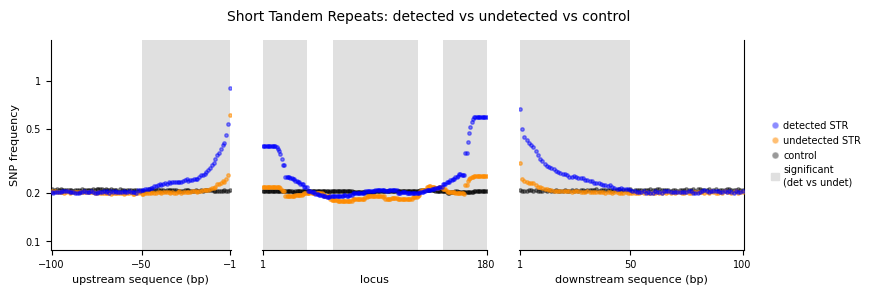

In [16]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

COL_DET   = (0/255, 0/255, 255/255, 0.45)     # blue
COL_UND   = (255/255, 140/255, 0/255, 0.55)   # orange
COL_CTRL  = (0/255, 0/255, 0/255, 0.40)       # black
COL_SIG   = (0.88, 0.88, 0.88)
PT_SIZE   = 6
MIN_SIG_RUN = 5

def _filter_short_runs(mask, min_run=MIN_SIG_RUN):
    out = mask.copy()
    n = len(out); i = 0
    while i < n:
        if out[i]:
            j = i
            while j < n and out[j]: j += 1
            if j - i < min_run: out[i:j] = False
            i = j
        else:
            i += 1
    return out

all_vals = np.concatenate([
    det_left_freq, undet_left_freq, ctrl_left_freq,
    det_locus_freq, undet_locus_freq, ctrl_locus_freq,
    det_right_freq, undet_right_freq, ctrl_right_freq,
])
valid = all_vals[(all_vals > 0) & np.isfinite(all_vals)]
y_lo = valid.min() * 0.5 if len(valid) else 0.001
y_hi = valid.max() * 2.0 if len(valid) else 1.0
Y_TICKS = [t for t in [0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0] if y_lo <= t <= y_hi]
Y_FMT   = ticker.FuncFormatter(lambda x, _: f"{x:g}")

def _add_sig_shading(ax, xs, sig_mask):
    cleaned = _filter_short_runs(sig_mask)
    if cleaned.any():
        ax.fill_between(xs, y_lo, y_hi, where=cleaned,
                        color=COL_SIG, alpha=1.0, step="mid", zorder=0, edgecolor="none")

def plot_panel3(ax, x, fdet, fund, fct, sig, xlabel, show_y, is_left=False, is_right=False):
    _add_sig_shading(ax, x, sig)
    ax.scatter(x, fct,  s=PT_SIZE, color=COL_CTRL, zorder=2)
    ax.scatter(x, fund, s=PT_SIZE, color=COL_UND,  zorder=3)
    ax.scatter(x, fdet, s=PT_SIZE, color=COL_DET,  zorder=4)
    ax.set_yscale("log"); ax.set_ylim(y_lo, y_hi)
    ax.set_xlabel(xlabel, fontsize=8); ax.tick_params(labelsize=7)
    ax.spines["top"].set_visible(False)
    if show_y:
        ax.yaxis.set_major_locator(ticker.FixedLocator(Y_TICKS))
        ax.yaxis.set_major_formatter(Y_FMT)
        ax.yaxis.set_minor_locator(ticker.NullLocator())
    else:
        ax.yaxis.set_visible(False); ax.spines["left"].set_visible(False)
    if is_left:
        ax.spines["right"].set_visible(False)
    elif is_right:
        ax.spines["left"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)

fig = plt.figure(figsize=(9, 3))
gs = gridspec.GridSpec(1, 3, width_ratios=[60, 75, 75], wspace=0.15,
                       left=0.08, right=0.85, top=0.88, bottom=0.18)

ax0 = fig.add_subplot(gs[0])
plot_panel3(ax0, left_x, det_left_freq, undet_left_freq, ctrl_left_freq, sig_dvu_left,
            "upstream sequence (bp)", show_y=True, is_left=True)
ax0.set_xlim(-MAX_FLANK - 0.5, -0.5); ax0.set_xticks([-100, -50, -1])
ax0.set_ylabel("SNP frequency", fontsize=8)

ax1 = fig.add_subplot(gs[1])
plot_panel3(ax1, locus_x, det_locus_freq, undet_locus_freq, ctrl_locus_freq, sig_dvu_locus,
            "locus", show_y=False)
ax1.set_xlim(0.5, LOCUS_BINS + 0.5); ax1.set_xticks([1, LOCUS_BINS])

ax2 = fig.add_subplot(gs[2])
plot_panel3(ax2, right_x, det_right_freq, undet_right_freq, ctrl_right_freq, sig_dvu_right,
            "downstream sequence (bp)", show_y=False, is_right=True)
ax2.set_xlim(0.5, MAX_FLANK + 0.5); ax2.set_xticks([1, 50, 100])

fig.legend(
    handles=[
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_DET,  markersize=5, label="detected STR"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_UND,  markersize=5, label="undetected STR"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_CTRL, markersize=5, label="control"),
        Patch(facecolor=COL_SIG, edgecolor=COL_SIG, label="significant\n(det vs undet)"),
    ],
    fontsize=7, loc="center right", frameon=False,
    handlelength=0.8, handletextpad=0.4,
    bbox_to_anchor=(0.99, 0.5),
)
fig.suptitle("Short Tandem Repeats: detected vs undetected vs control", fontsize=10, y=0.98)

out_pdf = "str_snp_frequency_detected_vs_undetected_vs_control.pdf"
out_png = "str_snp_frequency_detected_vs_undetected_vs_control.png"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
fig.savefig(out_png, dpi=200, bbox_inches="tight")
print(f"saved {out_pdf} and {out_png}")
plt.show()

## 5.9b Plot — detected vs undetected vs control (official R IWTomics + ggplot)

Re-run the IWTomics significance test for **detected vs undetected** using the **official IWTomics R Bioconductor package** (Pini & Vantini 2017, IWTomics 1.36) instead of the in-notebook Python permutation `iwtomics()`, then re-plot the 3-panel figure (LeftFlank | Locus | RightFlank) using `ggplot2`. The blue (detected) / orange (undetected) / black (control) per-bin frequencies stay the same; the gray shading is now the official R IWTomics adjusted p-value < 0.01 mask for the **det vs undet** comparison, computed once per sub-part (3 separate `IWTomicsTest` calls).



### Running the R script

A standalone R script is saved at `iwtomics_str/run_iwtomics_str_dvu.R`. It reads `NCNRSTR.gnomAD.intersect` (detected) and `NCNR.STR.gnomAD.undet.intersect` (undetected) directly, builds per-locus matrices for the 3 sub-parts, and runs `IWTomicsTest(..., statistics="mean", B=1000)` once per sub-part. Outputs:

* `STR_detected_vs_undetected_IWTomics_left_0.01.RData`  -> `adj_pvalue_curve_left`
* `STR_detected_vs_undetected_IWTomics_locus_0.01.RData` -> `adj_pvalue_curve_locus`
* `STR_detected_vs_undetected_IWTomics_right_0.01.RData` -> `adj_pvalue_curve_right`

Run interactively:

```bash
$R_BIN
> source("/path/to/snp_af_analysis/iwtomics_str/run_iwtomics_str_dvu.R")
```

Or batch-run (slow on the undetected pool; use nohup/screen):

```bash
nohup $R_BIN --vanilla \
  /path/to/snp_af_analysis/iwtomics_str/run_iwtomics_str_dvu.R \
  > iwtomics_str_dvu.log 2>&1 &
```

The R script auto-detects `N_UNDET` from V4 of the undetected intersect file (and appends it to `split_counts.txt`), so it does not need to be recomputed by hand.

Once the three `.RData` files are on disk, run the plot cell below.


N_MOTIF=50353  N_UNDET=96250  N_CTRL=50769
building matrices (detected) ...
building matrices (undetected) ...
building matrices (control) ...
wrote iwt_str_dvu_freq_{LeftFlank,Locus,RightFlank}.csv
plotting via /home/haz19024/miniconda3/envs/r/bin/Rscript ...
saved str_snp_frequency_detected_vs_undetected_vs_control_iwtomics.{pdf,png}



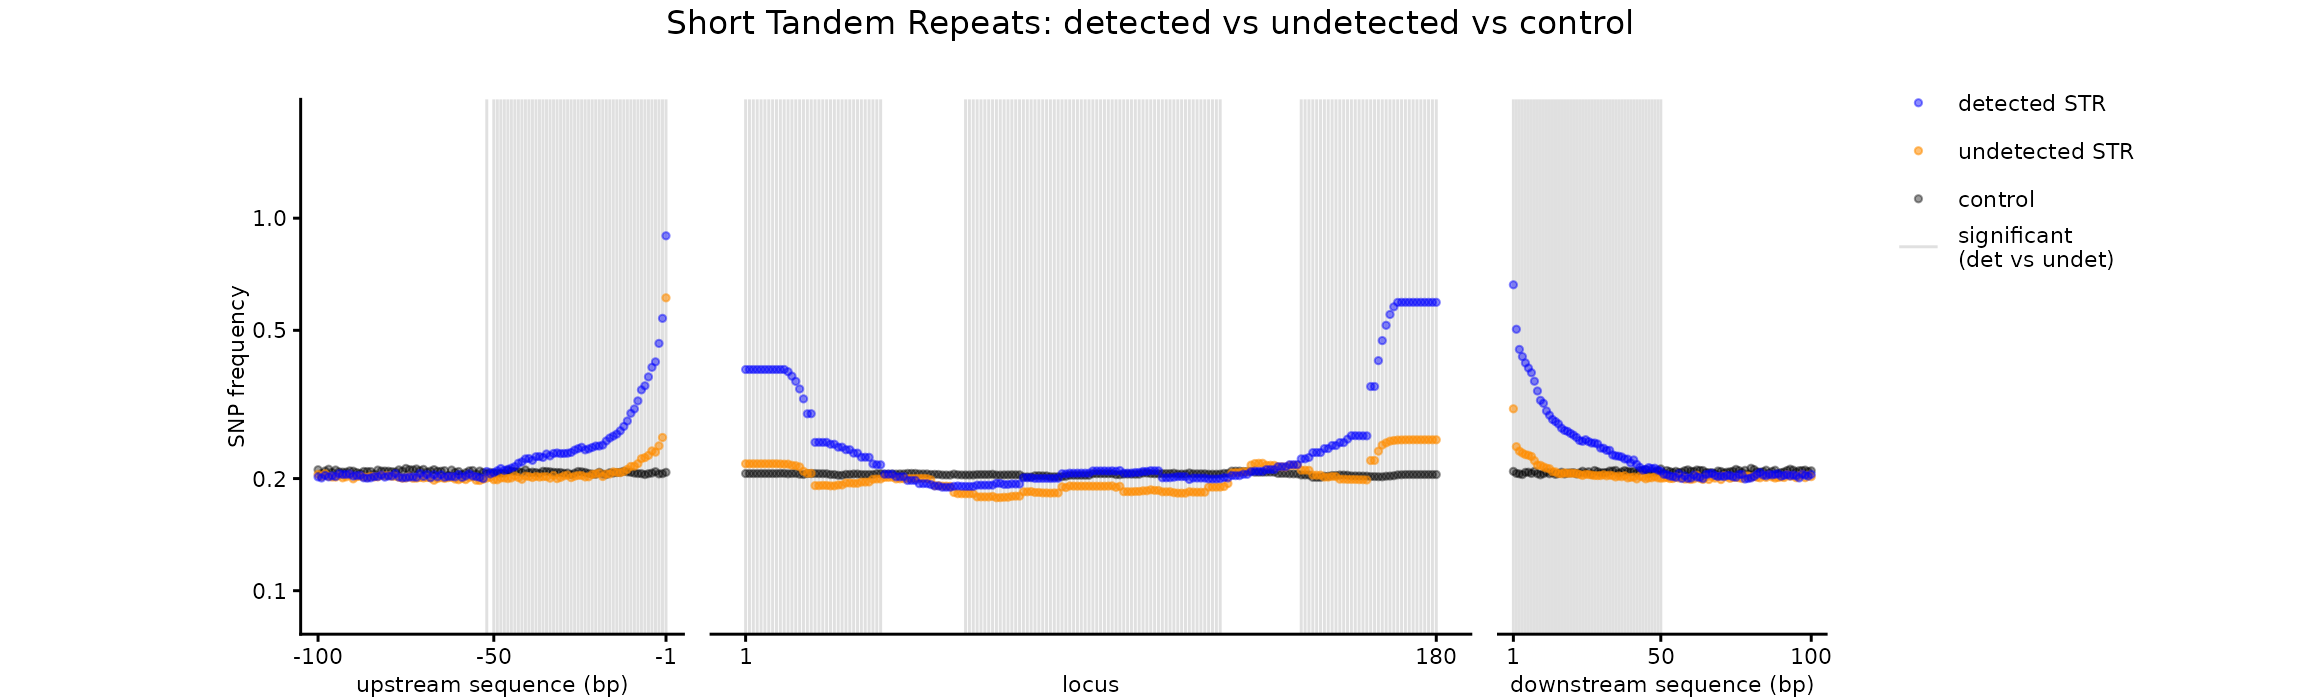

In [17]:
# R + ggplot 3-panel plot using official IWTomics .RData (det vs undet)
# Re-builds per-locus matrices for det/undet/ctrl from .intersect
# files (mirror of cell 20/25 _build_matrices), writes per-bin freq CSVs, then
# plots via R + ggplot. The gray shading is the IWTomics det-vs-undet
# significance from STR_detected_vs_undetected_IWTomics_*.RData.
import os, subprocess
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd

WORKDIR = "/path/to/snp_af_analysis/results/str_notebook_detected_run"
os.chdir(WORKDIR)

# parameters (must match run_iwtomics_str_dvu.R)
MAX_FLANK  = 100
LOCUS_BINS = 180
scaledposLocus = [round(i, 4) for i in np.arange(1, LOCUS_BINS * 2, 2.0) / (LOCUS_BINS * 2)]

# counts
def _read_counts():
    out = {}
    for line in Path("split_counts.txt").read_text().strip().splitlines():
        k, v = line.split("\t")
        out[k] = int(v)
    return out
_counts = _read_counts()
N_MOTIF = _counts["N_MOTIF"]
N_CTRL  = _counts["N_CTRL"]
# N_UNDET is appended to split_counts.txt by run_iwtomics_str_dvu.R; fall back
# to scanning V4 of the undet intersect if the script has not been run yet.
if "N_UNDET" in _counts:
    N_UNDET = _counts["N_UNDET"]
else:
    import subprocess as _sp
    N_UNDET = int(_sp.check_output(
        "awk -F'\t' '{if ($4+0 > m) m=$4+0} END{print m+1}' "
        "NCNR.STR.gnomAD.undet.intersect", shell=True).strip()) + 0
print(f"N_MOTIF={N_MOTIF}  N_UNDET={N_UNDET}  N_CTRL={N_CTRL}")

# build per-locus matrices (mirror of cell 20 _build_matrices)
def _build_matrices_iwt(intersect_path, n_loci):
    out = {
        "left":  np.zeros((n_loci, MAX_FLANK),  dtype=np.float32),
        "Locus": np.zeros((n_loci, LOCUS_BINS), dtype=np.float32),
        "right": np.zeros((n_loci, MAX_FLANK),  dtype=np.float32),
    }
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            if len(f) >= 6 and f[5] == ".": continue
            lid, ps, pe, ptype, snp_start = int(f[3]), int(f[1]), int(f[2]), f[4], int(f[6])
            key = (lid, ptype, snp_start)
            if key in seen: continue
            seen.add(key)
            plen = pe - ps
            if ptype == "LeftFlank":
                idx = -(pe - snp_start) + MAX_FLANK
                if 0 <= idx < MAX_FLANK: out["left"][lid, idx] += 1
            elif ptype == "RightFlank":
                idx = snp_start - ps
                if 0 <= idx < MAX_FLANK: out["right"][lid, idx] += 1
            elif ptype == "Locus" and plen > 0:
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(scaledposLocus):
                    if sp >= fs and sp < fe:
                        out["Locus"][lid, i] += 1
    return out

print("building matrices (detected) ...")
det = _build_matrices_iwt("NCNRSTR.gnomAD.intersect",            N_MOTIF)
print("building matrices (undetected) ...")
und = _build_matrices_iwt("NCNR.STR.gnomAD.undet.intersect",     N_UNDET)
print("building matrices (control) ...")
ctl = _build_matrices_iwt("NCNRSTR.gnomAD.shuffled.intersect",   N_CTRL)

# per-bin frequencies -> CSVs
def _freq(m, n): return m.sum(0) / n

pd.DataFrame({"LeftFlank":       _freq(det["left"],  N_MOTIF),
              "undet_LeftFlank": _freq(und["left"],  N_UNDET),
              "ctrl_LeftFlank":  _freq(ctl["left"],  N_CTRL)}
             ).to_csv("iwt_str_dvu_freq_LeftFlank.csv",  index=False)
pd.DataFrame({"RightFlank":       _freq(det["right"], N_MOTIF),
              "undet_RightFlank": _freq(und["right"], N_UNDET),
              "ctrl_RightFlank":  _freq(ctl["right"], N_CTRL)}
             ).to_csv("iwt_str_dvu_freq_RightFlank.csv", index=False)
pd.DataFrame({"Locus":       _freq(det["Locus"], N_MOTIF),
              "undet_Locus": _freq(und["Locus"], N_UNDET),
              "ctrl_Locus":  _freq(ctl["Locus"], N_CTRL)}
             ).to_csv("iwt_str_dvu_freq_Locus.csv", index=False)
print("wrote iwt_str_dvu_freq_{LeftFlank,Locus,RightFlank}.csv")

# R + ggplot
R_BIN = os.environ.get("R_BIN", "$R_BIN")

R_PLOT = r'''
suppressMessages({
  library(ggplot2); library(grid); library(gridExtra)
})

setwd("/path/to/snp_af_analysis/results/str_notebook_detected_run")

load("STR_detected_vs_undetected_IWTomics_left_0.01.RData")
load("STR_detected_vs_undetected_IWTomics_locus_0.01.RData")
load("STR_detected_vs_undetected_IWTomics_right_0.01.RData")

freqL <- read.csv("iwt_str_dvu_freq_LeftFlank.csv")
freqM <- read.csv("iwt_str_dvu_freq_Locus.csv")
freqR <- read.csv("iwt_str_dvu_freq_RightFlank.csv")

LeftFlankDf <- data.frame(Levels  = seq(-100, -1, 1),
                          DetFreq = freqL$LeftFlank,
                          UndFreq = freqL$undet_LeftFlank,
                          CtlFreq = freqL$ctrl_LeftFlank,
                          Signif  = adj_pvalue_curve_left$significant)
LocusDf     <- data.frame(Levels  = seq_len(180),
                          DetFreq = freqM$Locus,
                          UndFreq = freqM$undet_Locus,
                          CtlFreq = freqM$ctrl_Locus,
                          Signif  = adj_pvalue_curve_locus$significant)
RightFlankDf<- data.frame(Levels  = seq(1, 100, 1),
                          DetFreq = freqR$RightFlank,
                          UndFreq = freqR$undet_RightFlank,
                          CtlFreq = freqR$ctrl_RightFlank,
                          Signif  = adj_pvalue_curve_right$significant)

allv <- c(LeftFlankDf$DetFreq, LeftFlankDf$UndFreq, LeftFlankDf$CtlFreq,
          LocusDf$DetFreq,     LocusDf$UndFreq,     LocusDf$CtlFreq,
          RightFlankDf$DetFreq,RightFlankDf$UndFreq,RightFlankDf$CtlFreq)
allv <- allv[is.finite(allv) & allv > 0]
y_lo <- min(allv) * 0.5
y_hi <- max(allv) * 2

Y_BREAKS <- c(0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1)
Y_BREAKS <- Y_BREAKS[Y_BREAKS >= y_lo & Y_BREAKS <= y_hi]

cols <- c("detected STR"            = rgb(t(col2rgb("blue")),       alpha = 115, maxColorValue = 255),
          "undetected STR"          = rgb(t(col2rgb("darkorange")), alpha = 140, maxColorValue = 255),
          "control"                 = rgb(t(col2rgb("black")),      alpha = 100, maxColorValue = 255),
          "significant\n(det vs undet)" = "grey88")

p1 <- ggplot(LeftFlankDf, aes(x = Levels)) +
  geom_vline(xintercept = LeftFlankDf$Levels[LeftFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = CtlFreq, col = "control"),        size = 0.9) +
  geom_point(aes(y = UndFreq, col = "undetected STR"), size = 0.9) +
  geom_point(aes(y = DetFreq, col = "detected STR"),   size = 0.9) +
  theme_classic() +
  theme(legend.position = "none",
        axis.title  = element_text(size = 8, family = "sans"),
        axis.text.x = element_text(size = 8, family = "sans"),
        axis.text.y = element_text(size = 8, family = "sans")) +
  labs(y = "SNP frequency", x = "upstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(-100, -50, -1), limits = c(-100, -1)) +
  theme(plot.margin = unit(c(20, 5, 1, 1), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

p2 <- ggplot(LocusDf, aes(x = Levels)) +
  geom_vline(xintercept = LocusDf$Levels[LocusDf$Signif], col = "gray88") +
  geom_point(aes(y = CtlFreq, col = "control"),        size = 0.9) +
  geom_point(aes(y = UndFreq, col = "undetected STR"), size = 0.9) +
  geom_point(aes(y = DetFreq, col = "detected STR"),   size = 0.9) +
  theme_classic() +
  theme(legend.position = "none",
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank()) +
  labs(x = "locus") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(1, 180), limits = c(1, 180)) +
  theme(plot.margin = unit(c(20, 5, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

p3 <- ggplot(RightFlankDf, aes(x = Levels)) +
  geom_line(aes(x = 0, y = 0, colour = "significant\n(det vs undet)")) +
  geom_vline(xintercept = RightFlankDf$Levels[RightFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = CtlFreq, col = "control"),        size = 0.9) +
  geom_point(aes(y = UndFreq, col = "undetected STR"), size = 0.9) +
  geom_point(aes(y = DetFreq, col = "detected STR"),   size = 0.9) +
  theme_classic() +
  theme(axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank(),
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        legend.text  = element_text(size = 8, family = "sans"),
        legend.position  = c(1.55, 0.90),
        legend.background = element_rect(fill = "white", colour = NA)) +
  labs(x = "downstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols,
                      breaks = c("detected STR", "undetected STR", "control",
                                 "significant\n(det vs undet)")) +
  scale_x_continuous(breaks = c(1, 50, 100), limits = c(1, 100)) +
  theme(plot.margin = unit(c(20, 90, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS) +
  guides(shape = guide_legend(order = 3))

g <- arrangeGrob(p1, p2, p3, ncol = 3,
                 widths = unit(c(60, 100, 75), c("mm", "mm", "mm")),
                 top = textGrob("Short Tandem Repeats: detected vs undetected vs control",
                                gp = gpar(fontsize = 12, family = "sans")))

ggsave("str_snp_frequency_detected_vs_undetected_vs_control_iwtomics.pdf",
       g, width = 11.5, height = 3.5, dpi = 300, bg='white')
ggsave("str_snp_frequency_detected_vs_undetected_vs_control_iwtomics.png",
       g, width = 11.5, height = 3.5, dpi = 200, bg='white')
cat("saved str_snp_frequency_detected_vs_undetected_vs_control_iwtomics.{pdf,png}\n")
'''

Path("plot_str_dvu_iwtomics.R").write_text(R_PLOT)
print(f"plotting via {R_BIN} ...")
proc = subprocess.run([R_BIN, "--vanilla", "plot_str_dvu_iwtomics.R"],
                      capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr)
    raise RuntimeError(f"Rscript plot failed (code {proc.returncode})")

display(Image("str_snp_frequency_detected_vs_undetected_vs_control_iwtomics.png"))


# 6. All-test STR vs control

Plot every `label == 'Short_Tandem_Repeat'` row from `Short_Tandem_Repeat_test.csv` against its own shuffled control. Same Z-DNA-style 3-part split (LeftFlank | Locus | RightFlank, locus = 180 bins). The shuffle exclusion uses the **all-test STR pool** (not just detected) ∪ NCNR ∪ hg38 gaps.

## 6.1 Build all-test STR BED

In [18]:
# All-test STR BED (1-based -> 0-based half-open)
df_all_bed = df_all.copy()
df_all_bed["motif_start"] = df_all_bed["motif_start"] - 1
df_all_bed["motif_length"] = df_all_bed["motif_end"] - df_all_bed["motif_start"]
df_all_bed[["chr","motif_start","motif_end","motif_length"]].to_csv(
    "STR.all.bed", sep="\t", header=False, index=False)
print(f"wrote STR.all.bed with {len(df_all_bed)} rows")

wrote STR.all.bed with 563009 rows


In [19]:
%%bash
set -euo pipefail

# NCNR + 100bp threshold
bedtools intersect -a STR.all.bed -b NCNR.hg38.bed -v > NCNR.STR.all.bed
awk '{if ($3-$2<=100) print $0}' NCNR.STR.all.bed > NCNR.STR.all.100threshold.bed
bedtools sort -i NCNR.STR.all.100threshold.bed > NCNR.STR.all.100threshold.sorted.bed

paste NCNR.STR.all.100threshold.sorted.bed \
    <(bedtools slop -i NCNR.STR.all.100threshold.sorted.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2, "+", $2, $3, $4}' \
  > NCNR.STR.all.flanked.bed

wc -l STR.all.bed \
      NCNR.STR.all.bed \
      NCNR.STR.all.100threshold.sorted.bed \
      NCNR.STR.all.flanked.bed

  563009 STR.all.bed
  175936 NCNR.STR.all.bed
  175936 NCNR.STR.all.100threshold.sorted.bed
  175936 NCNR.STR.all.flanked.bed
 1090817 total


## 6.2 Build all-test control (excl = all-test STR ∪ NCNR ∪ gaps)

In [20]:
%%bash
set -euo pipefail

cut -f 1-3 NCNR.STR.all.100threshold.sorted.bed > _temp_STRall

cat _temp_STRall "$GAPS_BED" NCNR.hg38.bed \
  | cut -f1-3 \
  | sort -k1,1 -k2,2n | bedtools merge -i stdin > exclude_STR_all.bed

bedtools shuffle -i NCNR.STR.all.100threshold.sorted.bed \
    -excl exclude_STR_all.bed -g "$CHROM_SIZES" \
    -chrom -f 0 -noOverlapping -seed 45 > _temp_STRall_shuffled
bedtools sort -i _temp_STRall_shuffled > NCNR.STR.all.shuffled.bed

paste NCNR.STR.all.shuffled.bed \
    <(bedtools slop -i NCNR.STR.all.shuffled.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2+1, "+", $2, $3, $4}' \
  > NCNR.STR.all.shuffled.flanked.bed

rm -f _temp_STRall _temp_STRall_shuffled
wc -l NCNR.STR.all.shuffled.flanked.bed

175936 NCNR.STR.all.shuffled.flanked.bed


## 6.3 locuschoice + split + gnomAD intersect (all-test + its control)

In [21]:
locuschoice("NCNR.STR.all.flanked.bed",          "NCNR.STR.all.nooverlap.bed",          seed=46)
locuschoice("NCNR.STR.all.shuffled.flanked.bed", "NCNR.STR.all.shuffled.nooverlap.bed", seed=47)

n_all       = split_str("NCNR.STR.all.nooverlap.bed",          "NCNR.STR.all.split.bed")
n_all_ctrl  = split_str("NCNR.STR.all.shuffled.nooverlap.bed", "NCNR.STR.all.shuffled.split.bed")
N_ALL       = n_all
N_ALL_CTRL  = n_all_ctrl
print(f"N_ALL={N_ALL}  N_ALL_CTRL={N_ALL_CTRL}")

for p in ("NCNR.STR.all.split.bed", "NCNR.STR.all.shuffled.split.bed"):
    subprocess.run(f"bedtools sort -i {p} > _s.bed && mv _s.bed {p}", shell=True, check=True)

intersect_per_chrom("NCNR.STR.all.split.bed",          "NCNR.STR.all.gnomAD.intersect")
intersect_per_chrom("NCNR.STR.all.shuffled.split.bed", "NCNR.STR.all.gnomAD.shuffled.intersect")

NCNR.STR.all.flanked.bed -> NCNR.STR.all.nooverlap.bed: kept 127722
NCNR.STR.all.shuffled.flanked.bed -> NCNR.STR.all.shuffled.nooverlap.bed: kept 130986
NCNR.STR.all.nooverlap.bed -> NCNR.STR.all.split.bed: 127722 Loci
NCNR.STR.all.shuffled.nooverlap.bed -> NCNR.STR.all.shuffled.split.bed: 130986 Loci
N_ALL=127722  N_ALL_CTRL=130986
  skip chrY (no /data/haotian/qianying/snp_af_analysis/snp_data/gnomad/chrY_snps.bed)
NCNR.STR.all.split.bed -> NCNR.STR.all.gnomAD.intersect: 130662768 lines
  skip chrY (no /data/haotian/qianying/snp_af_analysis/snp_data/gnomad/chrY_snps.bed)
NCNR.STR.all.shuffled.split.bed -> NCNR.STR.all.gnomAD.shuffled.intersect: 135789390 lines


135789390

## 6.4 Matrices + IWTomics (all-test vs all-test-control)

In [22]:
print("Building per-locus matrices (all-test) …")
a_left, a_locus, a_right = _build_matrices("NCNR.STR.all.gnomAD.intersect",          N_ALL)
print("Building per-locus matrices (all-test control) …")
ac_left, ac_locus, ac_right = _build_matrices("NCNR.STR.all.gnomAD.shuffled.intersect", N_ALL_CTRL)

print("IWTomics – left flank (all-test vs control) …")
sig_avc_left  = iwtomics(a_left,  ac_left)
print(f"  significant positions: {sig_avc_left.sum()}/{MAX_FLANK}")
print("IWTomics – locus (all-test vs control) …")
sig_avc_locus = iwtomics(a_locus, ac_locus)
print(f"  significant bins: {sig_avc_locus.sum()}/{LOCUS_BINS}")
print("IWTomics – right flank (all-test vs control) …")
sig_avc_right = iwtomics(a_right, ac_right)
print(f"  significant positions: {sig_avc_right.sum()}/{MAX_FLANK}")

all_left_freq    = a_left.sum(0)  / N_ALL
all_locus_freq   = a_locus.sum(0) / N_ALL
all_right_freq   = a_right.sum(0) / N_ALL
ac_left_freq     = ac_left.sum(0)  / N_ALL_CTRL
ac_locus_freq    = ac_locus.sum(0) / N_ALL_CTRL
ac_right_freq    = ac_right.sum(0) / N_ALL_CTRL

print(f"\nall flank min/max:  {all_left_freq.min():.4f} .. {all_right_freq.max():.4f}")
print(f"all locus min/max:  {all_locus_freq.min():.4f} .. {all_locus_freq.max():.4f}")

Building per-locus matrices (all-test) …
Building per-locus matrices (all-test control) …
IWTomics – left flank (all-test vs control) …
  significant positions: 82/100
IWTomics – locus (all-test vs control) …
  significant bins: 145/180
IWTomics – right flank (all-test vs control) …
  significant positions: 86/100

all flank min/max:  0.1991 .. 0.4190
all locus min/max:  0.1829 .. 0.3602


## 6.5 Plot — all-test STR vs control

saved str_snp_frequency_all_vs_control.pdf and str_snp_frequency_all_vs_control.png


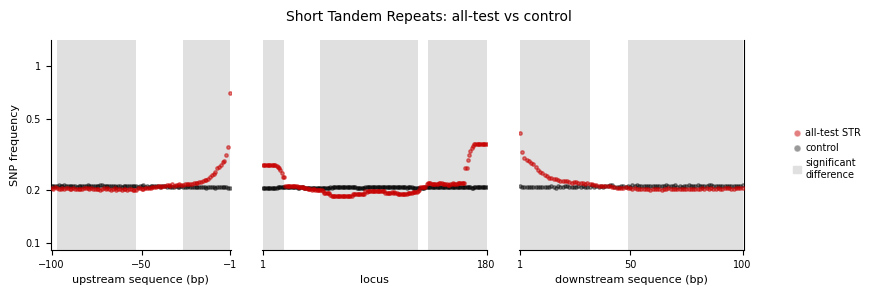

In [23]:
COL_ALL = (200/255, 0/255, 0/255, 0.5)   # red

all_vals2 = np.concatenate([
    all_left_freq, ac_left_freq,
    all_locus_freq, ac_locus_freq,
    all_right_freq, ac_right_freq,
])
valid2 = all_vals2[(all_vals2 > 0) & np.isfinite(all_vals2)]
y_lo2 = valid2.min() * 0.5 if len(valid2) else 0.001
y_hi2 = valid2.max() * 2.0 if len(valid2) else 1.0
Y_TICKS2 = [t for t in [0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0] if y_lo2 <= t <= y_hi2]

def _add_sig_shading2(ax, xs, sig_mask):
    cleaned = _filter_short_runs(sig_mask)
    if cleaned.any():
        ax.fill_between(xs, y_lo2, y_hi2, where=cleaned,
                        color=COL_SIG, alpha=1.0, step="mid", zorder=0, edgecolor="none")

def plot_panel2(ax, x, fa, fct, sig, xlabel, show_y, is_left=False, is_right=False):
    _add_sig_shading2(ax, x, sig)
    ax.scatter(x, fct, s=PT_SIZE, color=COL_CTRL, zorder=2)
    ax.scatter(x, fa,  s=PT_SIZE, color=COL_ALL,  zorder=3)
    ax.set_yscale("log"); ax.set_ylim(y_lo2, y_hi2)
    ax.set_xlabel(xlabel, fontsize=8); ax.tick_params(labelsize=7)
    ax.spines["top"].set_visible(False)
    if show_y:
        ax.yaxis.set_major_locator(ticker.FixedLocator(Y_TICKS2))
        ax.yaxis.set_major_formatter(Y_FMT)
        ax.yaxis.set_minor_locator(ticker.NullLocator())
    else:
        ax.yaxis.set_visible(False); ax.spines["left"].set_visible(False)
    if is_left:
        ax.spines["right"].set_visible(False)
    elif is_right:
        ax.spines["left"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)

fig2 = plt.figure(figsize=(9, 3))
gs2 = gridspec.GridSpec(1, 3, width_ratios=[60, 75, 75], wspace=0.15,
                        left=0.08, right=0.85, top=0.88, bottom=0.18)

ax0 = fig2.add_subplot(gs2[0])
plot_panel2(ax0, left_x, all_left_freq, ac_left_freq, sig_avc_left,
            "upstream sequence (bp)", show_y=True, is_left=True)
ax0.set_xlim(-MAX_FLANK - 0.5, -0.5); ax0.set_xticks([-100, -50, -1])
ax0.set_ylabel("SNP frequency", fontsize=8)

ax1 = fig2.add_subplot(gs2[1])
plot_panel2(ax1, locus_x, all_locus_freq, ac_locus_freq, sig_avc_locus,
            "locus", show_y=False)
ax1.set_xlim(0.5, LOCUS_BINS + 0.5); ax1.set_xticks([1, LOCUS_BINS])

ax2 = fig2.add_subplot(gs2[2])
plot_panel2(ax2, right_x, all_right_freq, ac_right_freq, sig_avc_right,
            "downstream sequence (bp)", show_y=False, is_right=True)
ax2.set_xlim(0.5, MAX_FLANK + 0.5); ax2.set_xticks([1, 50, 100])

fig2.legend(
    handles=[
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_ALL,  markersize=5, label="all-test STR"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_CTRL, markersize=5, label="control"),
        Patch(facecolor=COL_SIG, edgecolor=COL_SIG, label="significant\ndifference"),
    ],
    fontsize=7, loc="center right", frameon=False,
    handlelength=0.8, handletextpad=0.4,
    bbox_to_anchor=(0.99, 0.5),
)
fig2.suptitle("Short Tandem Repeats: all-test vs control", fontsize=10, y=0.98)

out_pdf2 = "str_snp_frequency_all_vs_control.pdf"
out_png2 = "str_snp_frequency_all_vs_control.png"
fig2.savefig(out_pdf2, dpi=300, bbox_inches="tight")
fig2.savefig(out_png2, dpi=200, bbox_inches="tight")
print(f"saved {out_pdf2} and {out_png2}")
plt.show()

## 6.6 Plot — all-test STR vs control (official R IWTomics + ggplot)

Re-run the IWTomics significance test for **all-test STR vs all-test control** using the **official IWTomics R Bioconductor package** (Pini & Vantini 2017, IWTomics 1.36) instead of the in-notebook Python permutation `iwtomics()`, then re-plot the 3-panel figure (LeftFlank | Locus | RightFlank) using `ggplot2`. The red (all-test STR) and black (control) per-bin frequencies stay the same; the gray shading is now the official R IWTomics adjusted p-value < 0.01 mask, computed once per sub-part (3 separate `IWTomicsTest` calls).



### Running the R script

A standalone R script is saved at `iwtomics_str/run_iwtomics_str_avc.R`. It reads `NCNR.STR.all.gnomAD.intersect` and `NCNR.STR.all.gnomAD.shuffled.intersect` directly, builds per-locus matrices for the 3 sub-parts, and runs `IWTomicsTest(..., statistics="mean", B=1000)` once per sub-part. Outputs:

* `STR_alltest_vs_control_IWTomics_left_0.01.RData`  -> `adj_pvalue_curve_left`
* `STR_alltest_vs_control_IWTomics_locus_0.01.RData` -> `adj_pvalue_curve_locus`
* `STR_alltest_vs_control_IWTomics_right_0.01.RData` -> `adj_pvalue_curve_right`

Run interactively:

```bash
$R_BIN
> source("/path/to/snp_af_analysis/iwtomics_str/run_iwtomics_str_avc.R")
```

Or batch-run (slow on the all-test pool; use nohup/screen):

```bash
nohup $R_BIN --vanilla \
  /path/to/snp_af_analysis/iwtomics_str/run_iwtomics_str_avc.R \
  > iwtomics_str_avc.log 2>&1 &
```

The R script auto-detects `N_ALL` and `N_ALL_CTRL` from V4 of the intersect files (and appends them to `split_counts.txt`).

Once the three `.RData` files are on disk, run the plot cell below.


N_ALL=127720  N_ALL_CTRL=130984
building matrices (all-test) ...
building matrices (all-test control) ...
wrote iwt_str_avc_freq_{LeftFlank,Locus,RightFlank}.csv
plotting via /home/haz19024/miniconda3/envs/r/bin/Rscript ...
saved str_snp_frequency_all_vs_control_iwtomics.{pdf,png}



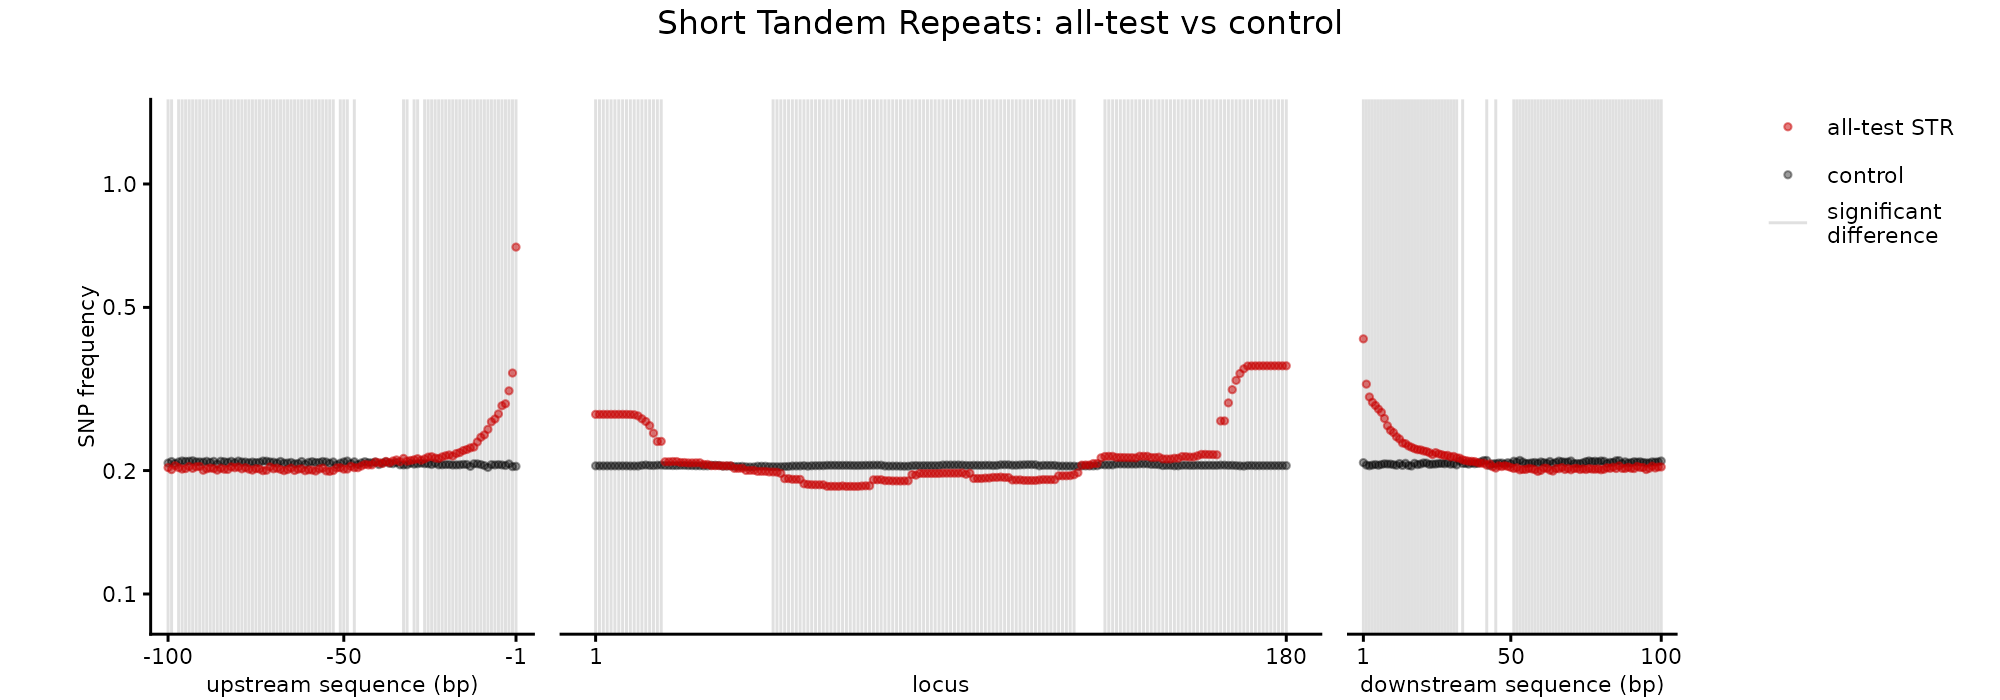

In [24]:
# R + ggplot 3-panel plot using official IWTomics .RData (all-test vs ctrl)
# Re-builds per-locus matrices for all-test/control from
# .intersect files, writes per-bin freq CSVs, then plots via R + ggplot.
import os, subprocess
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd

WORKDIR = "/path/to/snp_af_analysis/results/str_notebook_detected_run"
os.chdir(WORKDIR)

MAX_FLANK  = 100
LOCUS_BINS = 180
scaledposLocus = [round(i, 4) for i in np.arange(1, LOCUS_BINS * 2, 2.0) / (LOCUS_BINS * 2)]

# Counts: N_ALL / N_ALL_CTRL are appended by run_iwtomics_str_avc.R; fall back
# to scanning the intersect files if the script has not been run yet.
def _read_counts():
    out = {}
    for line in Path("split_counts.txt").read_text().strip().splitlines():
        k, v = line.split("\t")
        out[k] = int(v)
    return out
_counts = _read_counts()
def _scan_max(path):
    import subprocess as _sp
    return int(_sp.check_output(
        f"awk -F'\t' '{{if ($4+0 > m) m=$4+0}} END{{print m+1}}' {path}",
        shell=True).strip())
N_ALL      = _counts.get("N_ALL",      _scan_max("NCNR.STR.all.gnomAD.intersect"))
N_ALL_CTRL = _counts.get("N_ALL_CTRL", _scan_max("NCNR.STR.all.gnomAD.shuffled.intersect"))
print(f"N_ALL={N_ALL}  N_ALL_CTRL={N_ALL_CTRL}")

def _build_matrices_iwt(intersect_path, n_loci):
    out = {
        "left":  np.zeros((n_loci, MAX_FLANK),  dtype=np.float32),
        "Locus": np.zeros((n_loci, LOCUS_BINS), dtype=np.float32),
        "right": np.zeros((n_loci, MAX_FLANK),  dtype=np.float32),
    }
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            if len(f) >= 6 and f[5] == ".": continue
            lid, ps, pe, ptype, snp_start = int(f[3]), int(f[1]), int(f[2]), f[4], int(f[6])
            key = (lid, ptype, snp_start)
            if key in seen: continue
            seen.add(key)
            plen = pe - ps
            if ptype == "LeftFlank":
                idx = -(pe - snp_start) + MAX_FLANK
                if 0 <= idx < MAX_FLANK: out["left"][lid, idx] += 1
            elif ptype == "RightFlank":
                idx = snp_start - ps
                if 0 <= idx < MAX_FLANK: out["right"][lid, idx] += 1
            elif ptype == "Locus" and plen > 0:
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(scaledposLocus):
                    if sp >= fs and sp < fe:
                        out["Locus"][lid, i] += 1
    return out

print("building matrices (all-test) ...")
allm = _build_matrices_iwt("NCNR.STR.all.gnomAD.intersect",          N_ALL)
print("building matrices (all-test control) ...")
ctlm = _build_matrices_iwt("NCNR.STR.all.gnomAD.shuffled.intersect", N_ALL_CTRL)

def _freq(m, n): return m.sum(0) / n

pd.DataFrame({"LeftFlank":      _freq(allm["left"],  N_ALL),
              "ctrl_LeftFlank": _freq(ctlm["left"],  N_ALL_CTRL)}
             ).to_csv("iwt_str_avc_freq_LeftFlank.csv",  index=False)
pd.DataFrame({"RightFlank":      _freq(allm["right"], N_ALL),
              "ctrl_RightFlank": _freq(ctlm["right"], N_ALL_CTRL)}
             ).to_csv("iwt_str_avc_freq_RightFlank.csv", index=False)
pd.DataFrame({"Locus":      _freq(allm["Locus"], N_ALL),
              "ctrl_Locus": _freq(ctlm["Locus"], N_ALL_CTRL)}
             ).to_csv("iwt_str_avc_freq_Locus.csv", index=False)
print("wrote iwt_str_avc_freq_{LeftFlank,Locus,RightFlank}.csv")

R_BIN = os.environ.get("R_BIN", "$R_BIN")

R_PLOT = r'''
suppressMessages({
  library(ggplot2); library(grid); library(gridExtra)
})

setwd("/path/to/snp_af_analysis/results/str_notebook_detected_run")

load("STR_alltest_vs_control_IWTomics_left_0.01.RData")
load("STR_alltest_vs_control_IWTomics_locus_0.01.RData")
load("STR_alltest_vs_control_IWTomics_right_0.01.RData")

freqL <- read.csv("iwt_str_avc_freq_LeftFlank.csv")
freqM <- read.csv("iwt_str_avc_freq_Locus.csv")
freqR <- read.csv("iwt_str_avc_freq_RightFlank.csv")

LeftFlankDf  <- data.frame(Levels = seq(-100, -1, 1),
                           Freq   = freqL$LeftFlank,
                           C_Freq = freqL$ctrl_LeftFlank,
                           Signif = adj_pvalue_curve_left$significant)
LocusDf      <- data.frame(Levels = seq_len(180),
                           Freq   = freqM$Locus,
                           C_Freq = freqM$ctrl_Locus,
                           Signif = adj_pvalue_curve_locus$significant)
RightFlankDf <- data.frame(Levels = seq(1, 100, 1),
                           Freq   = freqR$RightFlank,
                           C_Freq = freqR$ctrl_RightFlank,
                           Signif = adj_pvalue_curve_right$significant)

allv <- c(LeftFlankDf$Freq,  LeftFlankDf$C_Freq,
          LocusDf$Freq,      LocusDf$C_Freq,
          RightFlankDf$Freq, RightFlankDf$C_Freq)
allv <- allv[is.finite(allv) & allv > 0]
y_lo <- min(allv) * 0.5
y_hi <- max(allv) * 2

Y_BREAKS <- c(0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1)
Y_BREAKS <- Y_BREAKS[Y_BREAKS >= y_lo & Y_BREAKS <= y_hi]

cols <- c("all-test STR"            = rgb(200, 0, 0, 130, maxColorValue = 255),
          "control"                 = rgb(t(col2rgb("black")), alpha = 100, maxColorValue = 255),
          "significant\ndifference" = "grey88")

p1 <- ggplot(LeftFlankDf, aes(x = Levels)) +
  geom_vline(xintercept = LeftFlankDf$Levels[LeftFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = C_Freq, col = "control"),      size = 0.9) +
  geom_point(aes(y = Freq,   col = "all-test STR"), size = 0.9) +
  theme_classic() +
  theme(legend.position = "none",
        axis.title  = element_text(size = 8, family = "sans"),
        axis.text.x = element_text(size = 8, family = "sans"),
        axis.text.y = element_text(size = 8, family = "sans")) +
  labs(y = "SNP frequency", x = "upstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(-100, -50, -1), limits = c(-100, -1)) +
  theme(plot.margin = unit(c(20, 5, 1, 1), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

p2 <- ggplot(LocusDf, aes(x = Levels)) +
  geom_vline(xintercept = LocusDf$Levels[LocusDf$Signif], col = "gray88") +
  geom_point(aes(y = C_Freq, col = "control"),      size = 0.9) +
  geom_point(aes(y = Freq,   col = "all-test STR"), size = 0.9) +
  theme_classic() +
  theme(legend.position = "none",
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank()) +
  labs(x = "locus") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(1, 180), limits = c(1, 180)) +
  theme(plot.margin = unit(c(20, 5, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

p3 <- ggplot(RightFlankDf, aes(x = Levels)) +
  geom_line(aes(x = 0, y = 0, colour = "significant\ndifference")) +
  geom_vline(xintercept = RightFlankDf$Levels[RightFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = C_Freq, col = "control"),      size = 0.9) +
  geom_point(aes(y = Freq,   col = "all-test STR"), size = 0.9) +
  theme_classic() +
  theme(axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank(),
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        legend.text  = element_text(size = 8, family = "sans"),
        legend.position  = c(1.55, 0.90),
        legend.background = element_rect(fill = "white", colour = NA)) +
  labs(x = "downstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols,
                      breaks = c("all-test STR", "control",
                                 "significant\ndifference")) +
  scale_x_continuous(breaks = c(1, 50, 100), limits = c(1, 100)) +
  theme(plot.margin = unit(c(20, 90, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS) +
  guides(shape = guide_legend(order = 3))

g <- arrangeGrob(p1, p2, p3, ncol = 3,
                 widths = unit(c(60, 100, 75), c("mm", "mm", "mm")),
                 top = textGrob("Short Tandem Repeats: all-test vs control",
                                gp = gpar(fontsize = 12, family = "sans")))

ggsave("str_snp_frequency_all_vs_control_iwtomics.pdf",
       g, width = 10, height = 3.5, dpi = 300, bg='white')
ggsave("str_snp_frequency_all_vs_control_iwtomics.png",
       g, width = 10, height = 3.5, dpi = 200, bg='white')
cat("saved str_snp_frequency_all_vs_control_iwtomics.{pdf,png}\n")
'''

Path("plot_str_avc_iwtomics.R").write_text(R_PLOT)
print(f"plotting via {R_BIN} ...")
proc = subprocess.run([R_BIN, "--vanilla", "plot_str_avc_iwtomics.R"],
                      capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr)
    raise RuntimeError(f"Rscript plot failed (code {proc.returncode})")

display(Image("str_snp_frequency_all_vs_control_iwtomics.png"))


## 7. STR SNP frequency vs repeat count (faceted by k-mer)

Non-positional view of STR variation. Each locus is collapsed to a scalar SNP rate and
grouped by **k-mer length** (= sum of `composition` counts in `features`) and **number of
repeats** (= `N` in `xN+M`). Because k-mers occupy non-overlapping repeat-count ranges
(1-mer 10–19, 4-mer 3–4, …), a shared x-axis is meaningless, so the panels are **faceted by k-mer** with
a **per-facet y-scale**.

- x = number of repeats; y = pooled SNP frequency (ΣSNP/Σbp); color = detected / undetected;
  grey dashed = MR-style matched control.
- control = 1:1 length-matched `bedtools shuffle` (excl = STR ∪ gaps ∪ NCNR), inherits each
  locus's k-mer/repeat-count; empirically flat at ~0.23 SNPs/bp.
- significance: per-(k-mer, repeat-count) permutation test of pooled SNP rate, real vs matched
  control (N=1000, α=0.01); `*` marks significant points. Groups with < `RC_NMIN` loci hidden.

Reuses `locuschoice` (5.4), `STR_BED` (5.1), `TEST_CSV` (5.8), and env from the setup cell.

In [ ]:
# 7.1-7.4  Build labeled motif beds (detected/undetected) + MR-style matched control
import csv as _csv
_csv.field_size_limit(10**7)

RC_MAXLEN = 100      # motif length threshold (bp)
RC_NMIN   = 50       # min loci per (group,kmer,nrep) to plot / test
RC_NPERM  = 1000
RC_ALPHA  = 0.01

def _rc_period(comp):
    return sum(int(re.match(r'(\d+)([ACGT])', t).group(1)) for t in comp.split('/'))

# 7.1 feature map from test CSV: (chr, mstart_1based, mend) -> (kmer, nrep)
rc_feat = {}
with open(TEST_CSV) as fh:
    r = _csv.reader(fh); h = next(r)
    ci=h.index('chr'); li=h.index('label'); fi=h.index('features')
    si=h.index('motif_start'); ei=h.index('motif_end')
    for row in r:
        if row[li] != 'Short_Tandem_Repeat' or not row[si] or not row[ei]:
            continue
        d={}; xc=None
        for p in row[fi].split(';'):
            if '=' in p: k,v=p.split('=',1); d[k]=v
            elif re.match(r'x\d+\+\d+', p): xc=p
        if 'composition' not in d or xc is None: continue
        rc_feat[(row[ci], int(float(row[si])), int(float(row[ei])))] = (
            _rc_period(d['composition']), int(re.match(r'x(\d+)\+', xc).group(1)))
print(f'test STR loci with features: {len(rc_feat)}')

# 7.2 detected set (1-based) from detected.bed
rc_det = set()
_dd = pd.read_csv(STR_BED, sep='\t').dropna(subset=['motif_start','motif_end'])
for c,s,e in zip(_dd['chr'], _dd['motif_start'].astype(int), _dd['motif_end'].astype(int)):
    rc_det.add((c,s,e))
print(f'detected loci: {len(rc_det)}')

# 7.3 labeled motif bed (0-based, name=group|kmer|nrep, <=100bp) + all-STR exclusion bed
with open('rc_loci.bed','w') as f:
    for (c,s1,e),(kmer,nrep) in rc_feat.items():
        start=s1-1; L=e-start
        if L<=0 or L>RC_MAXLEN: continue
        grp = 'detected' if (c,s1,e) in rc_det else 'undetected'
        f.write(f'{c}\t{start}\t{e}\t{grp}|{kmer}|{nrep}\n')
with open('rc_str_all.bed','w') as f:
    for (c,s1,e) in rc_feat:
        f.write(f'{c}\t{s1-1}\t{e}\n')
subprocess.run('bedtools intersect -a rc_loci.bed -b NCNR.hg38.bed -v '
               '| sort -k1,1 -k2,2n > rc_loci.ncnr.bed', shell=True, check=True)
locuschoice('rc_loci.ncnr.bed', 'rc_loci.nooverlap.bed', seed=42)

# 7.4 MR-style matched control: shuffle (name preserved), excl = STR ∪ gaps ∪ NCNR
subprocess.run('cat rc_str_all.bed "$GAPS_BED" NCNR.hg38.bed | cut -f1-3 '
               '| sort -k1,1 -k2,2n | bedtools merge -i stdin > rc_exclude.bed',
               shell=True, check=True)
subprocess.run('bedtools shuffle -i rc_loci.ncnr.bed -excl rc_exclude.bed '
               '-g "$CHROM_SIZES" -chrom -f 0 -noOverlapping -seed 42 '
               "| awk 'BEGIN{OFS=\"\\t\"}{split($4,a,\"|\"); print $1,$2,$3,\"control|\"a[2]\"|\"a[3]}' "
               '| sort -k1,1 -k2,2n > rc_ctrl.bed', shell=True, check=True)
locuschoice('rc_ctrl.bed', 'rc_ctrl.nooverlap.bed', seed=43)

In [ ]:
# 7.5  Per-locus SNP counts via bedtools intersect -c (per chrom, -sorted)
def rc_intersect_count(in_bed, out_path):
    snp_dir = os.environ['SNP_DIR']
    chroms = sorted(set(l.split('\t')[0] for l in open(in_bed)))
    with open(out_path,'w') as fout:
        for c in chroms:
            snp = f'{snp_dir}/{c}_snps.bed'
            if not os.path.exists(snp):
                print('  skip', c); continue
            cmd = f"awk '$1==\"{c}\"' {in_bed} | bedtools intersect -a stdin -b {snp} -c -sorted"
            fout.write(subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout)
    print(f'{in_bed} -> {out_path}')

rc_intersect_count('rc_loci.nooverlap.bed', 'rc_loci.counts.bed')
rc_intersect_count('rc_ctrl.nooverlap.bed', 'rc_ctrl.counts.bed')

In [ ]:
# 7.6  Aggregate pooled SNPs/bp + per-group permutation test vs matched control
from collections import defaultdict
rc_loci = defaultdict(list)   # (group,kmer,nrep) -> list of (snp, bp)
def _rc_load(path):
    for line in open(path):
        a=line.rstrip('\n').split('\t')
        if len(a)<5: continue
        grp,kmer,nrep=a[3].split('|')
        rc_loci[(grp,int(kmer),int(nrep))].append((int(a[4]), int(a[2])-int(a[1])))
_rc_load('rc_loci.counts.bed'); _rc_load('rc_ctrl.counts.bed')

def _rc_pooled(pairs):
    s=sum(x[0] for x in pairs); b=sum(x[1] for x in pairs)
    return s/b if b else np.nan

def _rc_perm(real, ctrl, nperm=RC_NPERM, seed=42):
    # two-sample permutation on the pooled SNPs/bp difference (the plotted metric)
    rng=np.random.default_rng(seed)
    allp=np.array(real+ctrl, dtype=float); n1=len(real); n=len(allp)
    obs=abs(_rc_pooled(real)-_rc_pooled(ctrl)); snp=allp[:,0]; bp=allp[:,1]; cnt=0
    for _ in range(nperm):
        idx=rng.permutation(n); a=idx[:n1]; b=idx[n1:]
        if abs(snp[a].sum()/bp[a].sum() - snp[b].sum()/bp[b].sum()) >= obs: cnt+=1
    return (cnt+1)/(nperm+1)

rc_df = pd.DataFrame([dict(group=g,kmer=k,nrep=n,n=len(p),
                           snp=sum(x[0] for x in p), bp=sum(x[1] for x in p),
                           freq=_rc_pooled(p)) for (g,k,n),p in rc_loci.items()])
rc_df['sig']=False; rc_df['pval']=np.nan
for kmer in sorted(rc_df.kmer.unique()):
    for nrep in sorted(rc_df[rc_df.kmer==kmer].nrep.unique()):
        ctrl=rc_loci.get(('control',kmer,nrep),[])
        if len(ctrl)<RC_NMIN: continue
        for grp in ('detected','undetected'):
            real=rc_loci.get((grp,kmer,nrep),[])
            if len(real)<RC_NMIN: continue
            p=_rc_perm(real,ctrl); m=(rc_df.group==grp)&(rc_df.kmer==kmer)&(rc_df.nrep==nrep)
            rc_df.loc[m,'pval']=p; rc_df.loc[m,'sig']=p<RC_ALPHA
rc_df=rc_df.sort_values(['group','kmer','nrep']).reset_index(drop=True)
rc_df.to_csv('str_repeatcount_freq.csv', index=False)
rc_df

In [ ]:
# 7.7  Faceted plot: per-k-mer panel, per-facet y-scale, significance marks
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
RC_COL={'detected':'#d62728','undetected':'#1f77b4','control':'0.45'}
plot_df=rc_df[rc_df.n>=RC_NMIN].copy()
kmers=sorted(plot_df[plot_df.group!='control'].kmer.unique())
fig,axes=plt.subplots(1,len(kmers),figsize=(3.4*len(kmers),3.8),sharey=False)
if len(kmers)==1: axes=[axes]
for ax,k in zip(axes,kmers):
    vals=[]
    for grp in ('detected','undetected','control'):
        sub=plot_df[(plot_df.group==grp)&(plot_df.kmer==k)].sort_values('nrep')
        if not len(sub): continue
        ls='--' if grp=='control' else '-'
        ax.plot(sub.nrep,sub.freq,ls,color=RC_COL[grp],marker='o',ms=4,lw=1.6)
        vals+=list(sub.freq.values)
        for _,rr in sub[sub.sig].iterrows():
            ax.annotate('*',(rr.nrep,rr.freq),textcoords='offset points',
                        xytext=(0,4),ha='center',fontsize=11,color=RC_COL[grp])
    if vals:
        ax.set_yscale('log'); ax.set_ylim(min(vals)*0.9, max(vals)*1.15)
    ax.set_title(f'{k}-mer',fontsize=11); ax.set_xlabel('number of repeats'); ax.tick_params(labelsize=8)
    xs=sorted(plot_df[plot_df.kmer==k].nrep.unique())
    if xs: ax.set_xticks(xs)
axes[0].set_ylabel('SNP frequency (SNPs/bp)')
handles=[Line2D([0],[0],color=RC_COL[g],ls=('--' if g=='control' else '-'),marker='o',ms=4,lw=1.6,label=g)
         for g in ('detected','undetected','control')]
handles.append(Line2D([0],[0],marker='*',color='0.3',ls='',ms=9,label=f'sig vs ctrl (p<{RC_ALPHA})'))
axes[-1].legend(handles=handles,fontsize=8,frameon=False,loc='best')
fig.suptitle('STR SNP frequency vs repeat count, by k-mer (detected/undetected vs matched control)',fontsize=12)
fig.tight_layout(rect=[0,0,1,0.94])
fig.savefig('str_repeatcount_snp_frequency.pdf', bbox_inches='tight')
fig.savefig('str_repeatcount_snp_frequency.png', dpi=200, bbox_inches='tight')
print('saved str_repeatcount_snp_frequency.{pdf,png}')
plt.show()